# Иерархическая кластеризация пользователей на примере датасета online shoppers intention

**Целью** исследования является сегментация пользователей на основе их поведенческих паттернов и намерений совершить покупку с использованием методов кластерного анализа

Данная работа включает в себя следующие этапы:
1) Загрузка и первичный анализ данных
2) Подготовка, очистка и кодирование данных
3) Обучение моделей и подбор гиперпараметров
4) Интерпретация кластеров
5) Иерархическая кластеризация
6) Дендрограмма
7) Поиск аномалий

In [197]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [198]:
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 30)

## 1. Загрузка и первичный анализ данных

In [199]:
# Экспортируем датасет
df = pd.read_csv("online_shoppers_intention.csv")

# Удалим столбец таргетной переменной
df = df.drop(columns="Revenue")

# Выведем форму датасета
df.shape

(12330, 17)

In [200]:
# Список названий признаков датасета Online Shoppers Purchasing Intention
features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'Month',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType',
    'VisitorType',
    'Weekend',
    'Revenue'
]

# Список описаний для каждого признака (в том же порядке)
descriptions = [
    'Количество посещенных административных страниц',
    'Время (в секундах), проведенное на административных страницах',
    'Количество посещенных информационных страниц',
    'Время (в секундах), проведенное на информационных страницах',
    'Количество посещенных страниц, связанных с товарами/услугами',
    'Время (в секундах), проведенное на страницах с товарами/услугами',
    'Процент посетителей, которые покинули сайт после просмотра только одной страницы',
    'Процент посетителей, которые покинули сайт с данной страницы',
    'Монетарное значение страницы для пользователя (на основе данных e-commerce)',
    'Близость даты посещения к особому дню (праздники, распродажи): 0 — далеко, 1 — близко',
    'Месяц посещения сайта (Jan, Feb, Mar, Apr, May, June, Jul, Aug, Sep, Oct, Nov, Dec)',
    'Операционная система посетителя (числовой код)',
    'Браузер посетителя (числовой код)',
    'Географический регион посетителя (числовой код)',
    'Тип трафика/источник перехода (числовой код)',
    'Тип посетителя: Returning_Visitor, New_Visitor, Other',
    'Посещение в выходной день: 1 — да, 0 — нет',
    'Целевая переменная: 1 — совершил покупку, 0 — не совершил'
]

descriptions_table = pd.DataFrame({
    "Признак": features,
    "Описание": descriptions
})

descriptions_table

,Признак,Описание
0,Administrative,Количество посещенных административных страниц
1,Administrative_Duration,"Время (в секундах), проведенное на административных страницах"
2,Informational,Количество посещенных информационных страниц
3,Informational_Duration,"Время (в секундах), проведенное на информационных страницах"
4,ProductRelated,"Количество посещенных страниц, связанных с товарами/услугами"
5,ProductRelated_Duration,"Время (в секундах), проведенное на страницах с товарами/услугами"
6,BounceRates,"Процент посетителей, которые покинули сайт после просмотра только одной страницы"
7,ExitRates,"Процент посетителей, которые покинули сайт с данной страницы"
8,PageValues,Монетарное значение страницы для пользователя (на основе данных e-commerce)
9,SpecialDay,"Близость даты посещения к особому дню (праздники, распродажи): 0 — далеко, 1 — близко"


In [201]:
print(df.head())

   Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  Browser  Region  TrafficType        VisitorType  Weekend
0               0                      0.0              0                     0.0               1                 0.000000         0.20       0.20         0.0         0.0   Feb                 1        1       1            1  Returning_Visitor    False
1               0                      0.0              0                     0.0               2                64.000000         0.00       0.10         0.0         0.0   Feb                 2        2       1            2  Returning_Visitor    False
2               0                      0.0              0                     0.0               1                 0.000000         0.20       0.20         0.0         0.0   Feb                 4        1       9            3  Returning_Visit

In [202]:
# Выведем количество пропусков по столбцам
df.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
dtype: int64

In [203]:
df.describe(include=["bool", "object"])

,Month,VisitorType,Weekend
count,12330,12330,12330
unique,10,3,2
top,May,Returning_Visitor,False
freq,3364,10551,9462


In [204]:
df.describe(include="number").loc["count":"min"].T

,count,mean,std,min
Administrative,12330.0,2.315166,3.321784,0.0
Administrative_Duration,12330.0,80.818611,176.779107,0.0
Informational,12330.0,0.503569,1.270156,0.0
Informational_Duration,12330.0,34.472398,140.749294,0.0
ProductRelated,12330.0,31.731468,44.475503,0.0
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0
BounceRates,12330.0,0.022191,0.048488,0.0
ExitRates,12330.0,0.043073,0.048597,0.0
PageValues,12330.0,5.889258,18.568437,0.0
SpecialDay,12330.0,0.061427,0.198917,0.0


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [206]:
df.select_dtypes(include="number")

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,1,1,1,1
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,2,2,1,2
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,4,1,9,3
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,3,2,2,4
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,3,3,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,4,6,1,1
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,3,2,1,8
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,3,2,1,13
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,2,2,3,11


Как мы видим, тут присутствуют булевы значения и категориальные признаки:
- Показатель Weekend
- Показатель Revenue
- Показатель Visitor_type

Также существуют переменные содержащие числовые коды, которые могут повлиять на дальнейшую кластеризацию:
- OperatingSystems	
- Browser	
- Region	
- TrafficType	

 Пропущенные значения отстутствуют.

## 2. Подготовка очистка и кодирование данных

Посмотрим количество уникальных значений в столбцах для кодирования, чтобы в случае one-hot кодирования не раздувать признаковое пространство.

In [207]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

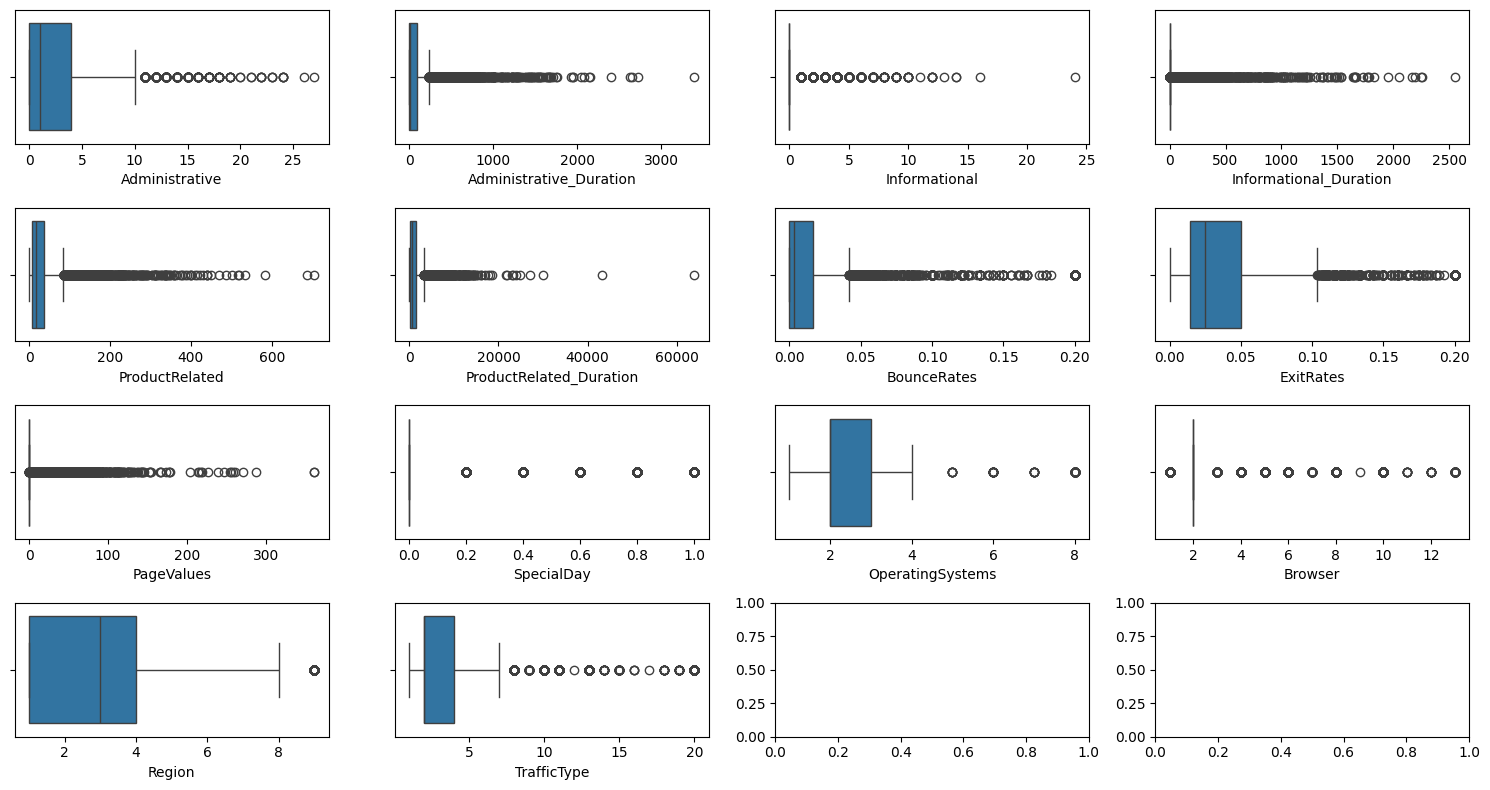

In [208]:
numeric_cols = df.select_dtypes(include="number").columns.to_list()
fig, axes = plt.subplots(4, 4, figsize=(15, 8))


for i, feature in enumerate(numeric_cols): 
    sns.boxplot(data=df, x=feature, ax=axes.flat[i])
plt.tight_layout()
plt.show()

Как мы видим, датасет содержит много строк, которые находятся за пределами IQR, но при этом, вероятно, выбросами не являются.

Аккуратно удалим значения, которые могут помешать дальнейшей кластеризации. Среди них выделим признаки:
- PageValues
- ProductRelated
- ProductRelatedDuration

In [209]:
df_cleaned = df[(df["PageValues"] <= 180) &
                (df["ProductRelated"] <= 400) &
                (df["ProductRelated_Duration"] <= 19000)
                ]
print(f"Удалено {len(df) - len(df_cleaned)}")

Удалено 36


Такое точечное удаление было выбрано из-за того, что IQR удалял примерно 20% всех семплов

In [210]:
print(f"TrafficType: {len(df_cleaned["TrafficType"].unique())}")
print(f"Region: {len(df_cleaned["Region"].unique())}")
print(f"Browser: {len(df_cleaned["Browser"].unique())}")
print(f"OperatingSystems: {len(df_cleaned["OperatingSystems"].unique())}")

TrafficType: 20
Region: 9
Browser: 13
OperatingSystems: 8


In [211]:
df_cleaned["Month"].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [212]:
df_cleaned["VisitorType"].unique()

array(['Returning_Visitor', 'New_Visitor', 'Other'], dtype=object)

In [213]:
# Приведем признаки к числовым значениям
df_cleaned["Weekend"] = df["Weekend"].map({False: 0, True: 1})

C:\Users\Кика\AppData\Local\Temp\ipykernel_19452\2859453593.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Weekend"] = df["Weekend"].map({False: 0, True: 1})


In [214]:
# Проведем one-hot кодирование категорий
feature_for_encode = ["VisitorType", "Month", "OperatingSystems"]
df_encoded = pd.get_dummies(df_cleaned, columns=feature_for_encode)

print(f"Признаковое пространство стало больше на {df_encoded.shape[1] - df.shape[1]} признаков")

Признаковое пространство стало больше на 18 признаков


In [215]:
# Стандартизируем признаки
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)



Доля объясненной дисперсии [0.09932482 0.06951841]
Суммарно: 0.16884322964319623


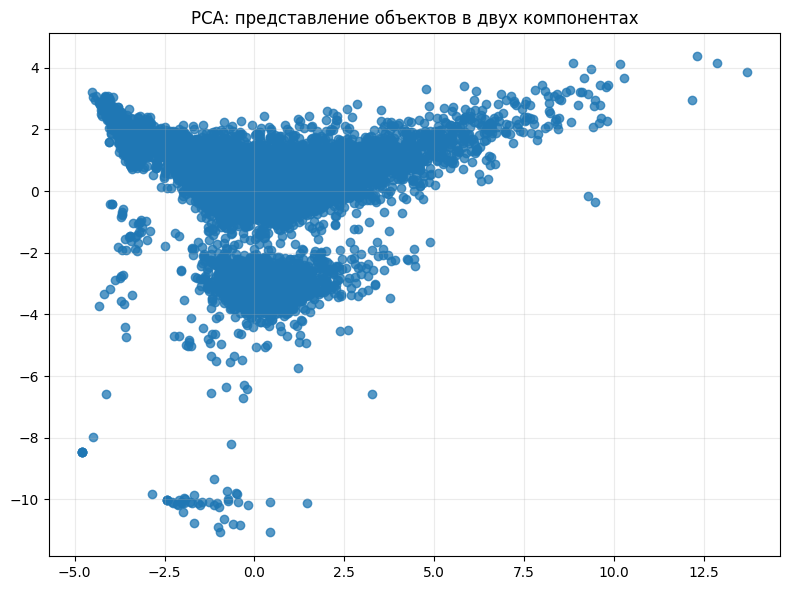

In [216]:
# Применим метод главных компонент для формирования новых признаков
pca_2d = PCA(n_components=2)

X_pca = pca_2d.fit_transform(X_scaled)

print("\nДоля объясненной дисперсии", pca_2d.explained_variance_ratio_)
print("Суммарно:", pca_2d.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.75)
plt.title("PCA: представление объектов в двух компонентах")
plt.grid(alpha=0.25)
plt.tight_layout()

Чисто визуально даннные делятся на 3 группы. 

Попробуем увеличить количество главных компонент для поднятия уровня объясненной дисперсии.

In [217]:
pca = PCA(
    n_components=17
)

pca.fit_transform(X_scaled)
print(f"Доля объясненной дисперсии {pca.explained_variance_ratio_.sum()}")

Доля объясненной дисперсии 0.7178168305817321


Лишь только при значительном увеличении числа компонент удалось достигнуть вменяемых результатов - 71% объясненной дисперсии.

Данные не сводятся к нескольким общим факторам, а зависят от многих. Также, возможно это вызвано one-hot кодированием



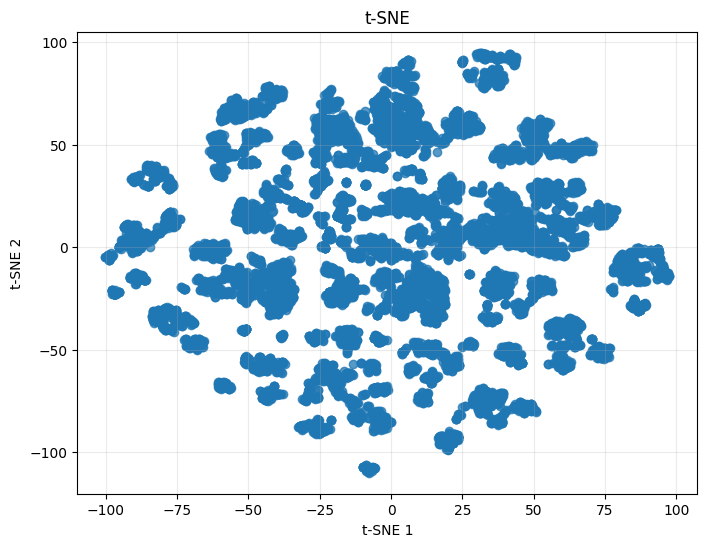

In [218]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.75)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE")
plt.grid(alpha=0.25)

t-SNE не дает особых результатов. Получается много маленьких кластеров внутри центрированного "облака" данных.

## 3. Обучение моделей и подбор гиперпараметров

In [219]:
scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k,
                   n_init=20,
                   random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append((k, score))

for k, s in scores:
    print(f"k = {k}, silhouette score = {s:.4f}")

# Поиск оптимального k - максимум по silhouette
k_optimal, best_score = max(scores, key=lambda x: x[1])

print(f"\n Наилучшее k = {k_optimal} (silhouette = {best_score:.4f})")

k = 2, silhouette score = 0.1609
k = 3, silhouette score = 0.1528
k = 4, silhouette score = 0.1482
k = 5, silhouette score = 0.0886
k = 6, silhouette score = 0.0989
k = 7, silhouette score = 0.1081
k = 8, silhouette score = 0.0933
k = 9, silhouette score = 0.1045
k = 10, silhouette score = 0.1313

 Наилучшее k = 2 (silhouette = 0.1609)


Наилучшее значение достигается при k = 2. Оно составляет 0,16.

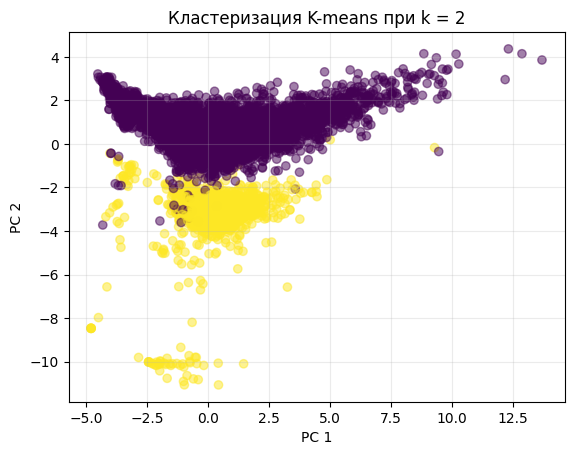

In [220]:
kmeans = KMeans(
    n_clusters=k_optimal,
    n_init=30,
    random_state=42
)

# Найдем метку для кластера
kmeans_labels = kmeans.fit_predict(X_scaled)

result = df_encoded.copy(deep=True)
result["Label"] = kmeans_labels

plt.scatter(x=X_pca[:, 0],
            y=X_pca[:, 1],
            c=kmeans_labels,
            alpha=0.5)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Кластеризация K-means при k = 2")
plt.grid(alpha=0.25)

Теперь мы видим весьма четкое разделение данных на 2 кластера.

## 4. Интепретация кластеров

In [221]:
important_features = [
                     'Administrative_Duration', 
                     'Informational_Duration', 
                     'ProductRelated', 'ProductRelated_Duration', 
                     'BounceRates',
                     'ExitRates', 
                     'PageValues',
                     'SpecialDay',
                     'TrafficType', 
                     'Weekend',
                     'VisitorType_New_Visitor',
                     'VisitorType_Other',
                     'VisitorType_Returning_Visitor'
                     ]
cluster_info = result.groupby("Label")[important_features].agg(["mean",
                                            "median"])

print(cluster_info.T)

Label                                           0           1
Administrative_Duration       mean      77.642550   90.720516
                              median     0.000000   46.300000
Informational_Duration        mean      36.113951   18.983349
                              median     0.000000    0.000000
ProductRelated                mean      33.228219   17.721877
                              median    19.000000   13.000000
ProductRelated_Duration       mean    1250.392860  630.992552
                              median   653.400000  396.500000
BounceRates                   mean       0.024829    0.006882
                              median     0.005263    0.000000
ExitRates                     mean       0.046582    0.022793
                              median     0.028421    0.013333
PageValues                    mean       4.883972    9.635944
                              median     0.000000    0.000000
SpecialDay                    mean       0.068618    0.019333
        

В данных кластерах действительно проглядывается явная структура.

ProductRelated, ProductRelated_Duration, VisitorType_Returning_Visitor в кластере под номером 0 свидетельствуют о том, что его можно коротко охарактеризовать как "постоянные клиенты". Об этом свидетельствует наибольшее время провенное за просмотром товаров, а также среднее значение показателя returning_visitor по кластеру "0" равное 1.

Если мы возьмем кластер под номером 1, то там показатель returning_visitor в среднем будет равен 0, в то время как new_visitor будет близок к единице. Также стоит отметить то, что время проведенное за просмотром товара у этой группы вдвое меньше группы 0. Подтверждает гипотезу также и тот факт, что новые пользователи чаще смотрят административную информацию по сайту, что и отображено в статистике по показателю Administrative_Duration. То есть кластер 1 можно охарактеризовать как "Новые пользователи".

## 5. Иерархическая кластеризация

K-means silhouette:        0.161
Hierarchical silhouette:   0.570


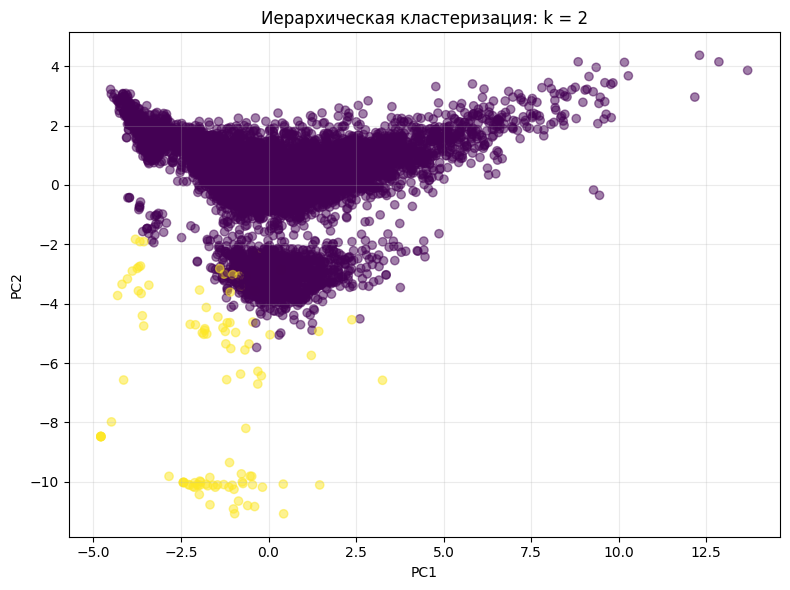

In [222]:
hierarchical = AgglomerativeClustering(n_clusters=k_optimal)
hier_labels = hierarchical.fit_predict(X_scaled)

result["cluster_hierarchical"] = hier_labels

hier_silhouette = silhouette_score(X_scaled, hier_labels)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)


print(f"K-means silhouette:        {kmeans_silhouette:.3f}")
print(f"Hierarchical silhouette:   {hier_silhouette:.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hier_labels,
    alpha=0.5,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Иерархическая кластеризация: k = {k_optimal}")
plt.grid(alpha=0.25)
plt.tight_layout()

Таким образом, иерархическая кластеризация визуально показывает похожее распределение объектов по кластерам, но при этом является более точной по показателю силуэта.

## 6. Дендрограмма

In [223]:
from scipy.cluster.hierarchy import linkage, dendrogram

Text(0.5, 1.0, 'Дендрограмма иерархической кластеризации')

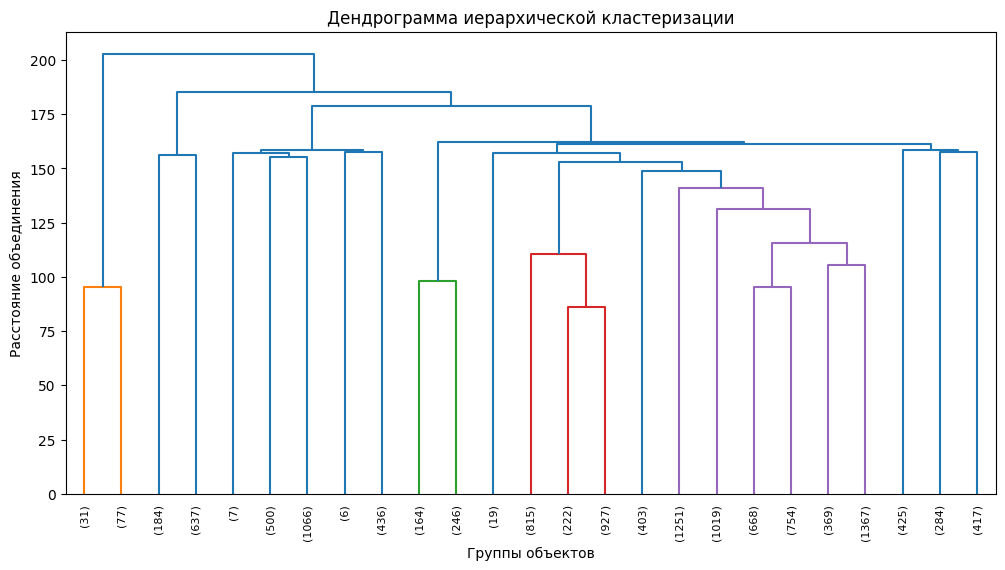

In [224]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=25,
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.xlabel("Группы объектов")
plt.ylabel("Расстояние объединения")
plt.title("Дендрограмма иерархической кластеризации")


Дендрограмма подтверждает, что данные плохо разделимы на кластеры. 

## 7. Поиск аномалий с помощью isolation forest

In [225]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
)

anomaly_label = isolation_forest.fit_predict(X_scaled)

#  1  = обычный объект
# -1  = потенциальная аномалия
result["is_anomaly"] = anomaly_label == -1

# Чем меньше score_samples, тем более необычным считается объект.
result["anomaly_score"] = isolation_forest.score_samples(X_scaled)

anomalies = (
    result[result["is_anomaly"]]
    .sort_values("anomaly_score")
)


print(f"Найдено кандидатов на аномалии: {len(anomalies)}")

columns_to_show = [
    "anomaly_score",
    *important_features[:4],
]

print("\nНаиболее необычные объекты:")
print(anomalies[columns_to_show].head(10).round(3))

Найдено кандидатов на аномалии: 615

Наиболее необычные объекты:
       anomaly_score  Administrative_Duration  Informational_Duration  ProductRelated  ProductRelated_Duration
5679          -0.630                    0.000                 225.767             222                 9630.210
6066          -0.611                 1220.914                1005.400             280                18171.795
9971          -0.606                 1103.330                 696.833             359                12959.915
12178         -0.606                 1561.718                 503.722             183                 9676.093
11385         -0.602                  106.000                   0.000              42                 1384.197
11682         -0.602                  213.500                   0.000              11                  303.500
12117         -0.596                   46.500                   0.000              14                  398.979
10024         -0.592                   97.833  

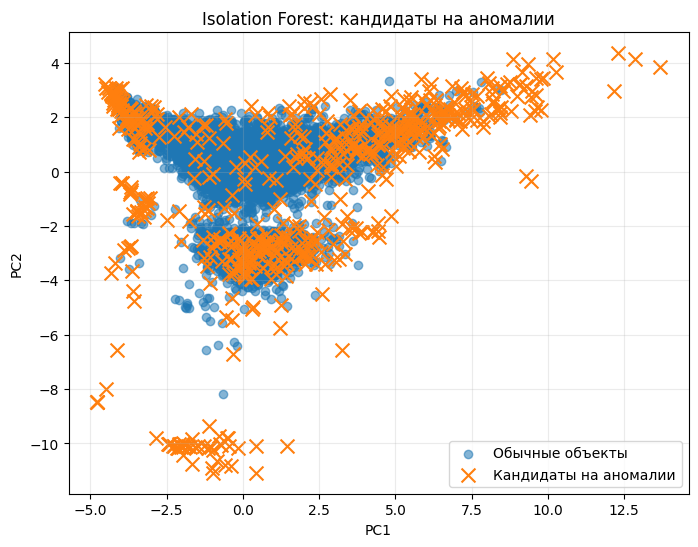

In [226]:
plt.figure(figsize=(8, 6))

normal_mask = ~result["is_anomaly"]
anomaly_mask = result["is_anomaly"]

plt.scatter(
    X_pca[normal_mask, 0],
    X_pca[normal_mask, 1],
    alpha=0.55,
    label="Обычные объекты",
)

plt.scatter(
    X_pca[anomaly_mask, 0],
    X_pca[anomaly_mask, 1],
    marker="x",
    s=100,
    label="Кандидаты на аномалии",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest: кандидаты на аномалии")
plt.legend()
plt.grid(alpha=0.25)

Уже на первый взгляд видно, что разделение получилось нечётким: оранжевые метки встречаются не только на периферии облака, но и в его плотной центральной части. Это тревожный сигнал, потому что аномалии по определению должны быть редкими и отделёнными от основной массы данных, а здесь они буквально «вкраплены» в нормальные объекты.

По графику можно сделать вывод о сложной неоднородной структуре данных, а также о дисбалансе классов, по всей видимости из-за которой многие семплы были отнесены к аномалиям.